In [ ]:
import os
from functools import reduce
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

try:
    spark.stop()
except:
    pass

spark = (SparkSession.builder
            .appName("TaxiDemandPrediction_HDFS")
            .config("spark.master", "yarn")
            .config("spark.submit.deployMode", "client")
            .config("spark.driver.memory", "3g")
            .config("spark.driver.cores", "2")
            .config("spark.driver.host", "192.168.1.111")
            .config("spark.driver.bindAddress", "0.0.0.0")
            .config("spark.driver.port", "7078")
            .config("spark.driver.blockManager.port", "7079")
            .config("spark.blockManager.port", "7080")
            .config("spark.executor.memory", "4g")
            .config("spark.executor.cores", "3")
            .config("spark.executor.memoryOverhead", "1024")
            .config("spark.executor.instances", "2")
            .config("spark.dynamicAllocation.enabled", "false")
            .config("spark.shuffle.service.enabled", "false")
            .config("spark.default.parallelism", "12")
            .config("spark.sql.shuffle.partitions", "12")
            .config("spark.sql.execution.arrow.pyspark.enabled", "true")
            .config("spark.eventLog.enabled", "true")
            .config("spark.eventLog.dir", "hdfs://192.168.1.111:9000/spark-logs")
            .getOrCreate()
)

print(f"Spark Session OK | Master: {spark.sparkContext.master}")
print(f"App ID: {spark.sparkContext.applicationId}")



print("\nĐang lấy danh sách files từ HDFS...")
# Dùng JVM của Spark để truy cập HDFS FileSystem
FileSystem = spark._jvm.org.apache.hadoop.fs.FileSystem
Path = spark._jvm.org.apache.hadoop.fs.Path
fs = FileSystem.get(spark.sparkContext._jsc.hadoopConfiguration())

data_path = "hdfs://192.168.1.111:9000/user/data/raw/"
file_statuses = fs.listStatus(Path(data_path))

# Lọc ra danh sách các file parquet chuyến đi
parquet_files = [str(file_status.getPath()) for file_status in file_statuses 
                 if str(file_status.getPath()).endswith(".parquet") and "yellow_tripdata_" in str(file_status.getPath())]

print(f"Tìm thấy {len(parquet_files)} file parquet.")

# Định nghĩa 5 cột chuẩn cần lấy
COLS_SELECT = [
    F.col("PULocationID").cast("long").alias("PULocationID"),
    F.col("tpep_pickup_datetime").cast("timestamp").alias("tpep_pickup_datetime"),
    F.col("tpep_dropoff_datetime").cast("timestamp").alias("tpep_dropoff_datetime"),
    F.col("trip_distance").cast("double").alias("trip_distance"),
    F.col("total_amount").cast("double").alias("total_amount")
]

dfs = []
for file in parquet_files:
    try:
        # Đọc TỪNG FILE ĐƠN, không dùng wildcard
        df_file = spark.read.parquet(file).select(COLS_SELECT)
        dfs.append(df_file)
    except Exception as e:
        print(f"Lỗi khi đọc file {file}: {e}")

print("\nĐang Union dữ liệu...")
# Union toàn bộ các file đã đồng nhất schema
df_taxi = reduce(lambda a, b: a.union(b), dfs)

# Lọc đúng 6 năm 2020-2025 (loại dữ liệu lỗi)
df_taxi = df_taxi.filter(
    (F.year("tpep_pickup_datetime") >= 2020) &
    (F.year("tpep_pickup_datetime") <= 2025)
)

print(f"\nTổng số bản ghi (2020-2025): {df_taxi.count():,}")

26/05/04 10:49:52 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.
26/05/04 10:49:55 WARN Client: Same path resource file:///root/.ivy2/jars/graphframes_graphframes-0.8.3-spark3.5-s_2.12.jar added multiple times to distributed cache.
26/05/04 10:49:55 WARN Client: Same path resource file:///root/.ivy2/jars/org.slf4j_slf4j-api-1.7.16.jar added multiple times to distributed cache.


Spark Session OK | Master: yarn
App ID: application_1777886124324_0003

Đang lấy danh sách files từ HDFS...
Tìm thấy 72 file parquet.



Đang Union dữ liệu...



Tổng số bản ghi (2020-2025): 223,410,839


In [11]:
# CELL 2 - Làm sạch + trích xuất đặc trưng thời gian
import pyspark.sql.functions as F

df_clean = df_taxi.dropna(subset=["PULocationID", "tpep_pickup_datetime", "tpep_dropoff_datetime"])
df_clean = df_clean.filter(
    (F.col("trip_distance") > 0) &
    (F.col("total_amount") > 0)
)
df_clean = df_clean \
    .withColumn("hour",       F.hour("tpep_pickup_datetime")) \
    .withColumn("day_of_week",F.dayofweek("tpep_pickup_datetime")) \
    .withColumn("month",      F.month("tpep_pickup_datetime")) \
    .withColumn("year",       F.year("tpep_pickup_datetime"))

print(f"Số bản ghi sau làm sạch: {df_clean.count():,}")

Số bản ghi sau làm sạch: 216,912,095


In [ ]:
# CELL 3 - Gán Borough (phân vùng địa lý) thay cho KMeans
#
# KMeans cũ dùng 1 feature PULocationID 
# không có ý nghĩa khoảng cách Euclidean).
# Thay bằng Borough từ taxi_zone_lookup.csv: phân vùng hành chính
# thực tế (Manhattan, Brooklyn, Queens, Bronx, Staten Island, EWR).

from pyspark.ml.feature import StringIndexer

# 1. Đọc bảng tra cứu zone → Borough
zone_lookup = spark.read.csv(
    "hdfs://192.168.1.111:9000/user/data/raw/taxi_zone_lookup.csv",
    header=True, inferSchema=True
)
print("Các Borough:")
zone_lookup.select("Borough").distinct().show(truncate=False)

# 2. Join PULocationID → Borough
df_with_borough = df_clean.join(
    zone_lookup.select("LocationID", "Borough"),
    df_clean["PULocationID"] == zone_lookup["LocationID"],
    "left"
).drop("LocationID")

# Bỏ Unknown / N/A
df_with_borough = df_with_borough.filter(
    ~F.col("Borough").isin(["Unknown", "N/A"]) & F.col("Borough").isNotNull()
)

# 3. Encode Borough → số
indexer = StringIndexer(inputCol="Borough", outputCol="borough_idx")
model_indexer = indexer.fit(df_with_borough)
df_clustered = model_indexer.transform(df_with_borough)

print("\nMapping Borough → borough_idx:")
for i, label in enumerate(model_indexer.labels):
    print(f"  {i}: {label}")

print(f"\nSố bản ghi sau gán Borough: {df_clustered.count():,}")

Các Borough:
+-------------+
|Borough      |
+-------------+
|Staten Island|
|Brooklyn     |
|Queens       |
|Bronx        |
|Unknown      |
|N/A          |
|Manhattan    |
|EWR          |
+-------------+




Mapping Borough → borough_idx:
  0: Manhattan
  1: Queens
  2: Brooklyn
  3: Bronx
  4: Staten Island
  5: EWR



Số bản ghi sau gán Borough: 215,308,701


In [13]:
# CELL 4 - GroupBy + toPandas
demand_df = df_clustered \
    .groupBy("borough_idx", "year", "month", "day_of_week", "hour") \
    .agg(F.count("*").alias("busy_score"))

print("Đang chuyển sang Pandas...")
pdf = demand_df.toPandas()

print(f"Shape: {pdf.shape}")
print(f"Năm: {sorted(pdf['year'].unique())}")
print(f"Borough idx: {sorted(pdf['borough_idx'].unique())}")
pdf.head()

Đang chuyển sang Pandas...


26/05/04 10:55:02 WARN DAGScheduler: Broadcasting large task binary with size 1042.2 KiB


Shape: (59426, 6)
Năm: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Borough idx: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


,borough_idx,year,month,day_of_week,hour,busy_score
0,0.0,2020,1,4,5,8594
1,0.0,2020,1,4,11,45165
2,1.0,2020,1,6,23,2935
3,2.0,2020,1,6,21,495
4,0.0,2020,1,7,15,42789


In [14]:
import os, glob

offline_dir = "/workspace/code/taxiflow_nyc/offline_packages"
if os.path.exists(offline_dir) and glob.glob(os.path.join(offline_dir, "*.whl")):
    print("Cài offline...")
    !pip install --no-index --find-links=file://{offline_dir} scikit-learn xgboost
else:
    print("Cài online...")
    !pip install scikit-learn xgboost joblib pyarrow

Cài offline...
Looking in links: file:///workspace/code/taxiflow_nyc/offline_packages


In [15]:
pdf.to_csv('/workspace/data/taxi_demand_features.csv', index=False)
print("Đã lưu CSV local.")

demand_df.write.mode("overwrite").parquet(
    "hdfs://192.168.1.111:9000/user/taxiflow_nyc/demand_features"
)
print("Đã lưu HDFS: /user/taxiflow_nyc/demand_features")

Đã lưu CSV local.


26/05/04 10:56:16 WARN DAGScheduler: Broadcasting large task binary with size 1042.2 KiB
26/05/04 10:57:26 WARN DAGScheduler: Broadcasting large task binary with size 1158.3 KiB


Đã lưu HDFS: /user/taxiflow_nyc/demand_features


In [16]:
# CELL 5 - Chuẩn bị dữ liệu cho ML
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

X = pdf[['borough_idx', 'year', 'month', 'day_of_week', 'hour']]
y = pdf['busy_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}\n")

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (47540, 5), Test: (11886, 5)


In [17]:
# CELL 6 - Linear Regression
print("Huấn luyện Linear Regression...")
lr_grid = GridSearchCV(
    LinearRegression(),
    {'fit_intercept': [True, False]},
    cv=5, scoring='neg_mean_squared_error'
)
lr_grid.fit(X_train, y_train)
evaluate_model("Linear Regression", y_test, lr_grid.best_estimator_.predict(X_test))

Huấn luyện Linear Regression...
--- Linear Regression ---
MSE : 41926859.4688
RMSE: 6475.0953
R2  : 0.3592



In [18]:
# CELL 7 - Random Forest
print("Huấn luyện Random Forest...")
rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [50,100,200], 'max_depth': [None,10,20], 'min_samples_split': [2,5,10]},
    n_iter=5, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1
)
rf_random.fit(X_train, y_train)
rf_best = rf_random.best_estimator_
evaluate_model("Random Forest", y_test, rf_best.predict(X_test))

Huấn luyện Random Forest...
--- Random Forest ---
MSE : 915671.6181
RMSE: 956.9073
R2  : 0.9860



In [19]:
# CELL 8 - XGBoost
print("Huấn luyện XGBoost...")
xgb_random = RandomizedSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    {'n_estimators': [100,200], 'learning_rate': [0.05,0.1,0.2],
     'max_depth': [3,5,7], 'subsample': [0.8,1.0]},
    n_iter=5, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1
)
xgb_random.fit(X_train, y_train)
xgb_best = xgb_random.best_estimator_
evaluate_model("XGBoost", y_test, xgb_best.predict(X_test))

Huấn luyện XGBoost...
--- XGBoost ---
MSE : 484111.3438
RMSE: 695.7811
R2  : 0.9926



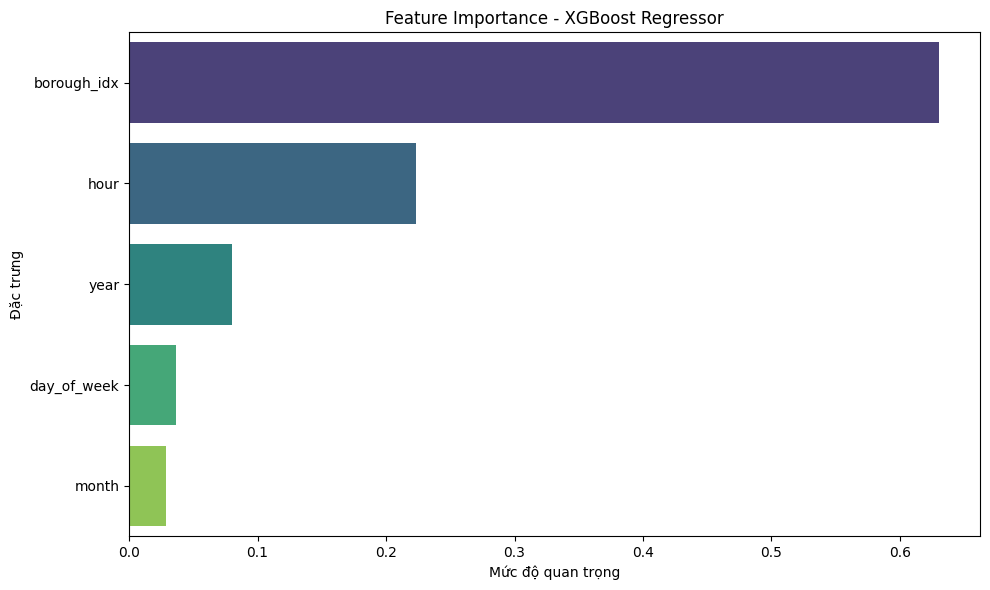

In [20]:
# CELL 9 - Feature Importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df,
            hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance - XGBoost Regressor')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

In [21]:
# CELL 10 - Lưu model
import joblib

model_filename = '/workspace/data/taxi_demand_xgboost_model.pkl'
joblib.dump(xgb_best, model_filename)
print(f"Đã lưu model tại: {model_filename}")

Đã lưu model tại: /workspace/data/taxi_demand_xgboost_model.pkl
